<a href="https://colab.research.google.com/github/sreenandinisreenivasan3-sree/ML-project/blob/main/Day6_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df=pd.read_csv('/content/fish.csv')
df.head()

,Bream,242.0,23.2,25.4,30.0,38.4,13.4
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2


In [ ]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Bream   84 non-null     object 
 1   242.0   84 non-null     float64
 2   23.2    84 non-null     float64
 3   25.4    84 non-null     float64
 4   30.0    84 non-null     float64
 5   38.4    84 non-null     float64
 6   13.4    84 non-null     float64
dtypes: float64(6), object(1)
memory usage: 4.7+ KB


In [ ]:
df.rename(columns={'Bream': 'Species',
                   '242.0': 'Weight',
                   '23.2': 'Length1',
                   '25.4': 'Length2',
                   '30.0': 'Length3',
                   '38.4': 'Height',
                   '13.4': 'Width'}, inplace=True)
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2


<Axes: >

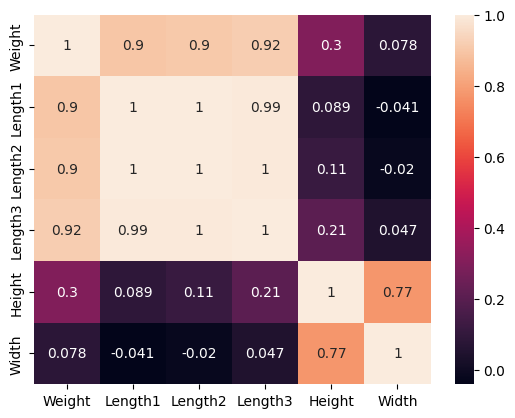

In [ ]:
data=df.drop(columns=['Species'])
sns.heatmap(data.corr(),annot=True)

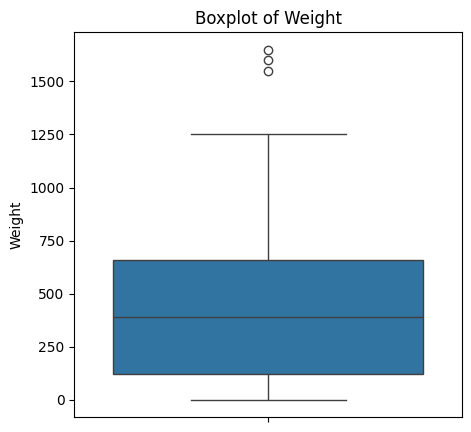

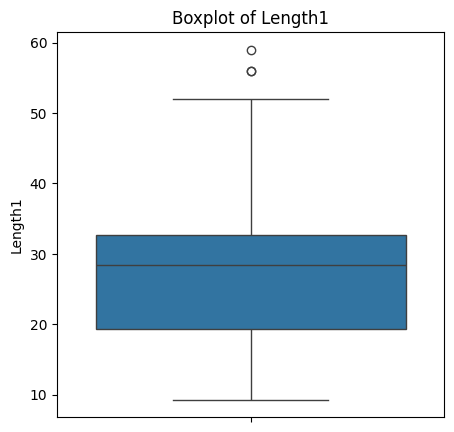

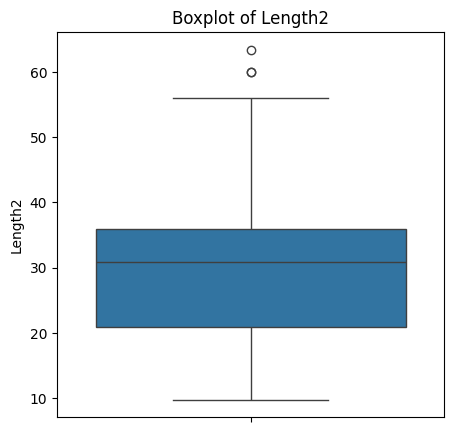

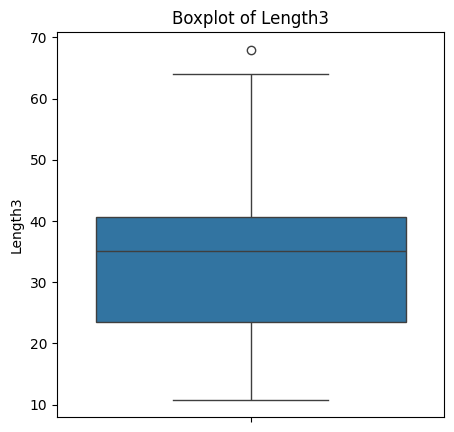

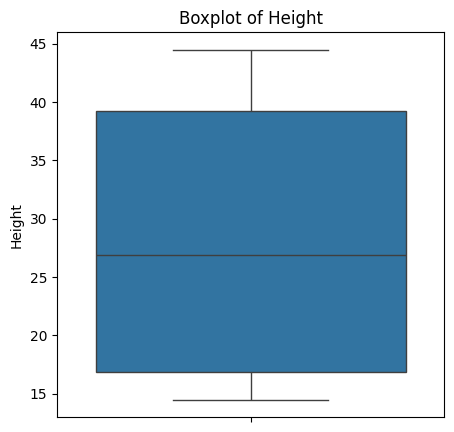

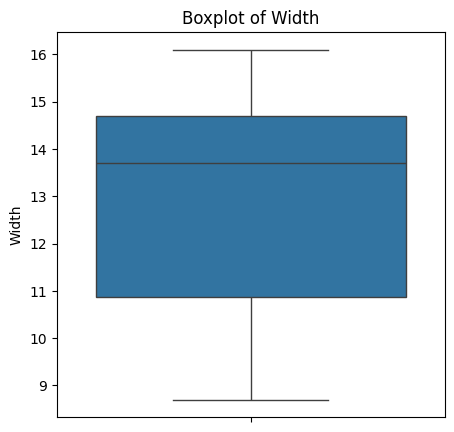

In [ ]:
num_cols=df.select_dtypes(include=np.number).columns
for col in num_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(y=df[col])
  plt.title(f'Boxplot of {col}')
  plt.show()

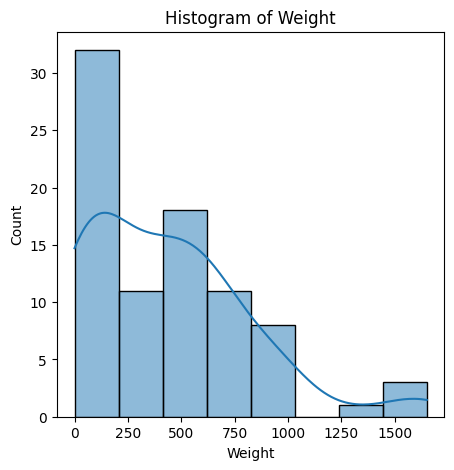

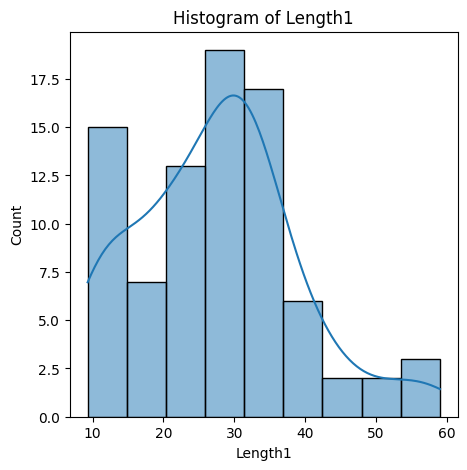

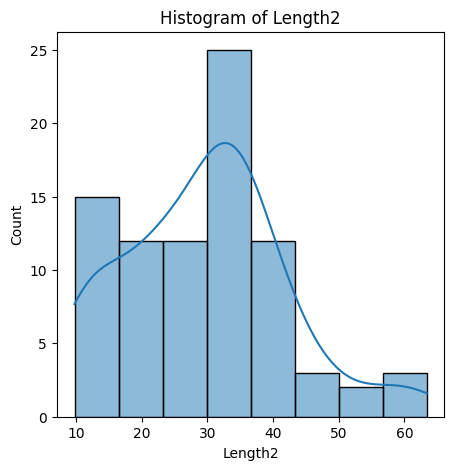

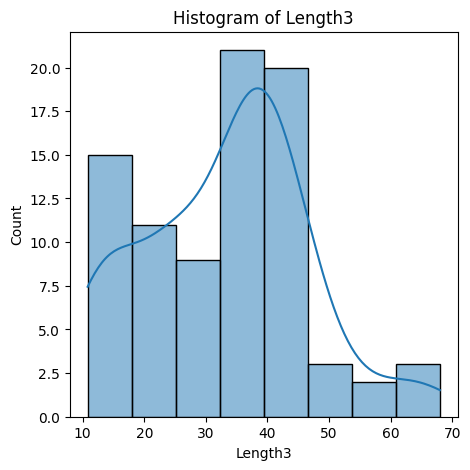

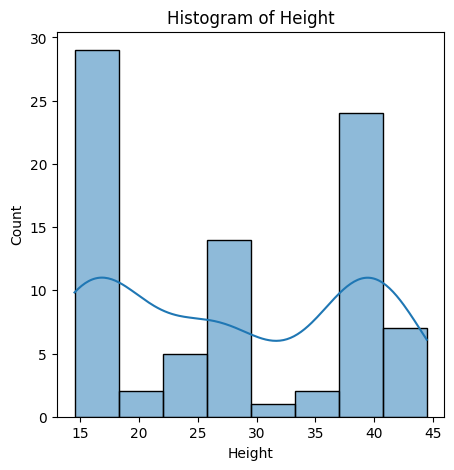

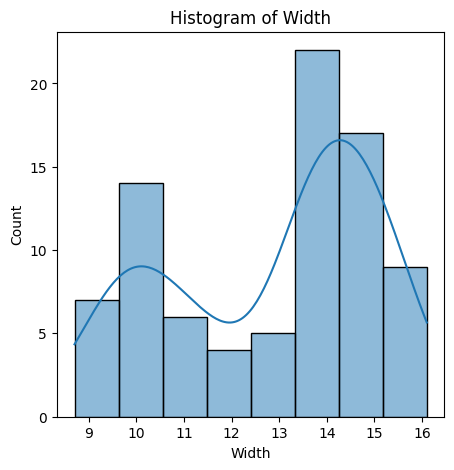

In [ ]:
num_cols=df.select_dtypes(include=np.number).columns
for col in num_cols:
  plt.figure(figsize=(5,5))
  sns.histplot(df[col],kde=True)
  plt.title(f'Histogram of {col}')
  plt.show()

In [ ]:
from scipy.stats.mstats import winsorize
for col in ['Weight','Length1','Length2','Length3']:
  data[col]=winsorize(data[col],(0,0.05))
data

,Weight,Length1,Length2,Length3,Height,Width
0,290.0,24.0,26.3,31.2,40.0,13.8
1,340.0,23.9,26.5,31.1,39.8,15.1
2,363.0,26.3,29.0,33.5,38.0,13.3
3,430.0,26.5,29.0,34.0,36.6,15.1
4,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...
79,950.0,48.3,51.7,55.1,16.2,11.2
80,1000.0,48.3,51.7,55.1,17.9,11.7
81,1000.0,48.3,51.7,55.1,15.0,9.6
82,1000.0,48.3,51.7,55.1,15.0,9.6


In [ ]:
from scipy.stats import skew
df['Width'].skew()

np.float64(-0.4942330151273134)

<Axes: xlabel='Weight', ylabel='Length1'>

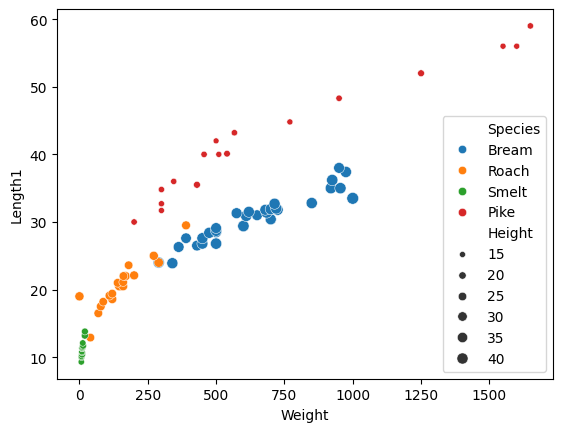

In [ ]:
sns.scatterplot(data=df,x='Weight',y='Length1',hue='Species',size='Height')

In [ ]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_scaled=ss.fit_transform(data)
x_scaled

array([[-0.37307155, -0.29008277, -0.2585373 , -0.12494199,  1.1707675 ,
         0.44432002],
       [-0.21712226, -0.29964594, -0.24082349, -0.13307145,  1.15132991,
         1.05849403],
       [-0.14538559, -0.0701299 , -0.01940084,  0.06203549,  0.97639163,
         0.20809925],
       [ 0.06358647, -0.05100356, -0.01940084,  0.10268277,  0.84032853,
         1.05849403],
       [ 0.12596619, -0.02231406,  0.0425975 ,  0.15958896,  1.09301715,
         0.63329664],
       [ 0.28191548, -0.02231406,  0.0425975 ,  0.14333005,  1.27767423,
         1.15298234],
       [-0.06117297,  0.05419129,  0.06916822,  0.18397733,  0.80145335,
         0.25534341],
       [ 0.12596619,  0.05419129,  0.06916822,  0.19210678,  1.16104871,
         0.44432002],
       [ 0.28191548,  0.1402598 ,  0.13116656,  0.2815308 ,  1.10273595,
         0.39707587],
       [ 0.20394083,  0.13069663,  0.15773727,  0.2815308 ,  1.11245474,
         0.58605249],
       [ 0.28191548,  0.15938614,  0.15773727,  0.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss=[]
sil_scores=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,
                random_state=42,
                init='k-means++',
                max_iter=300,
                n_init=10)
  kmeans.fit_predict(x_scaled)
  labels =kmeans.labels_
  wcss.append(kmeans.inertia_)
  sil_h=silhouette_score(x_scaled,labels)
  sil_scores.append(sil_h)

In [ ]:
for i,k in enumerate(range(2,11)):
  print(f"for k={k},wcss={wcss[i]:.2f} and sil_score={sil_scores[i]:.2f}")

for k=2,wcss=257.49 and sil_score=0.45
for k=3,wcss=135.04 and sil_score=0.54
for k=4,wcss=75.24 and sil_score=0.59
for k=5,wcss=51.81 and sil_score=0.60
for k=6,wcss=36.16 and sil_score=0.53
for k=7,wcss=30.41 and sil_score=0.53
for k=8,wcss=25.31 and sil_score=0.52
for k=9,wcss=21.01 and sil_score=0.46
for k=10,wcss=18.50 and sil_score=0.46


Text(0, 0.5, 'Silhouette Score')

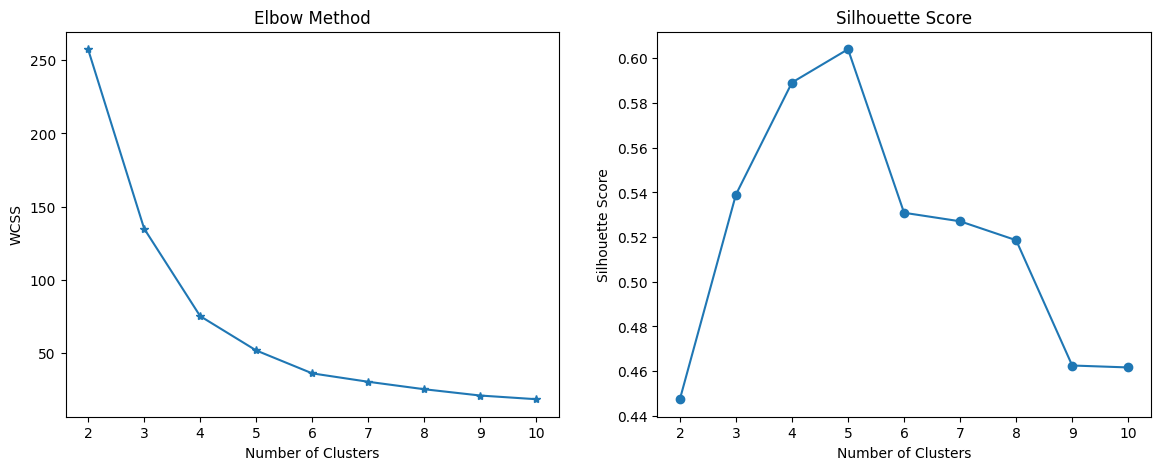

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(range(2,11),wcss,marker='*')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

In [ ]:
kmeans=KMeans(n_clusters=5,
                random_state=42,
                init='k-means++',
                max_iter=300,
                n_init=10)
kmeans.fit(x_scaled)
cluster_labels=kmeans.predict(x_scaled)
cluster_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1,
       3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4], dtype=int32)

In [ ]:
df['kmeans_cluster']=cluster_labels
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,kmeans_cluster
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,0
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,0
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,0
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,0
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,0


In [ ]:
df['kmeans_cluster'].value_counts()

,count
kmeans_cluster,
0,34
1,20
3,13
2,11
4,6


<Axes: xlabel='Weight', ylabel='Length1'>

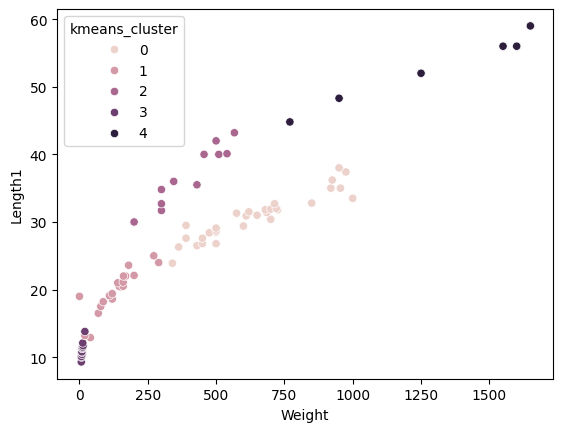

In [ ]:
sns.scatterplot(data=df,x='Weight',y='Length1',hue='kmeans_cluster')

In [ ]:
new_fish=np.array([[20,300,20,20,20,20]])
scled=ss.transform(new_fish)
cluster=kmeans.predict(scled)
cluster

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

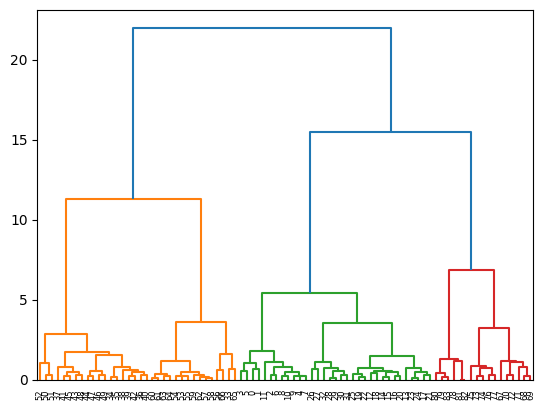

In [ ]:
from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.cluster import AgglomerativeClustering

merging=linkage(x_scaled,method='ward')
dendrogram(merging);

In [ ]:
ag_cl=AgglomerativeClustering(n_clusters=4,
                              metric='euclidean',
                              linkage='ward')
agg_clus=ag_cl.fit_predict(x_scaled)
agg_clus

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
df['agg_clus']=agg_clus
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,kmeans_cluster,agg_clus
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,0,2
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,0,2
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,0,2
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,0,2
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,0,2


In [ ]:
df.kmeans_cluster.value_counts()

,count
kmeans_cluster,
0,34
1,20
3,13
2,11
4,6


<Axes: xlabel='Weight', ylabel='Length1'>

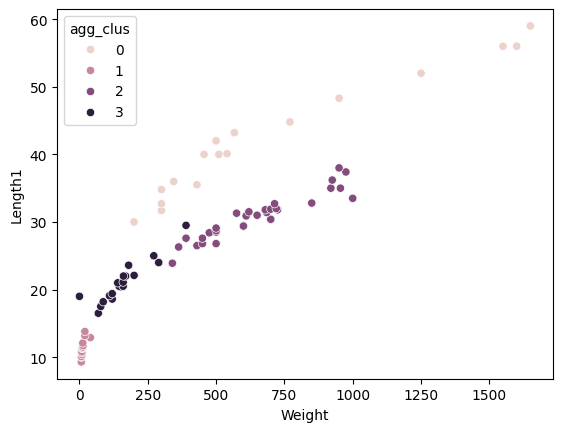

In [ ]:
sns.scatterplot(data=df,x='Weight',y='Length1',hue='agg_clus')

In [ ]:
sil_scores={}

for i in range(2,11):
  agg_clus=AgglomerativeClustering(n_clusters=i,
                              metric='euclidean',
                              linkage='ward')
  sil_h=silhouette_score(x_scaled,agg_clus.fit_predict(x_scaled))
  sil_scores[i]=sil_h

sil_scores

{2: np.float64(0.44029438983294655),
 3: np.float64(0.5317405959930687),
 4: np.float64(0.5642966948824016),
 5: np.float64(0.5794549380810812),
 6: np.float64(0.5103844656021281),
 7: np.float64(0.4852858619095591),
 8: np.float64(0.4915598261047463),
 9: np.float64(0.483147372485779),
 10: np.float64(0.47189013723685397)}

In [ ]:
from scipy.cluster .hierarchy import fcluster
cluster_labels=fcluster(merging,criterion='distance',t=10)
cluster_labels

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype=int32)

In [ ]:
from sklearn.cluster import DBSCAN

for e in [0.1,0.2,0.3,0.4,0.4,0.5,0.6,0.7]:
  db_scan=DBSCAN(eps=e,min_samples=5)

In [ ]:
db_labels=db_scan.fit_predict(x_scaled)
db_labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2, -1,  2, -1,
       -1, -1, -1, -1, -1,  3,  3,  3,  3,  3, -1,  4,  4,  4,  4,  4])

In [ ]:
df['db_cluster']=db_labels
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,kmeans_cluster,agg_clus,db_cluster
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,0,2,0
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,0,2,0
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,0,2,0
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,0,2,0
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,0,2,0


In [ ]:
df['db_cluster'].value_counts()

,count
db_cluster,
-1,36
0,22
1,15
2,11


<Axes: xlabel='Weight', ylabel='Length1'>

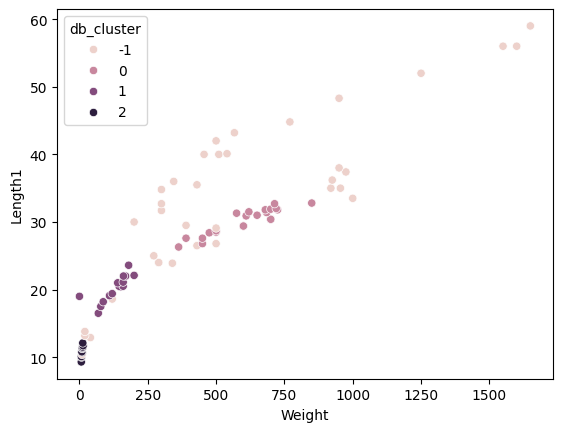

In [ ]:
sns.scatterplot(data=df,x='Weight',y='Length1',hue='db_cluster')

In [ ]:
sil_scores={}

for i in range(2,11):
  db_scan=DBSCAN()
  sil_h=silhouette_score(x_scaled,db_scan.fit_predict(x_scaled))
  sil_scores[i]=sil_h

sil_scores

{2: np.float64(0.317448800570763),
 3: np.float64(0.317448800570763),
 4: np.float64(0.317448800570763),
 5: np.float64(0.317448800570763),
 6: np.float64(0.317448800570763),
 7: np.float64(0.317448800570763),
 8: np.float64(0.317448800570763),
 9: np.float64(0.317448800570763),
 10: np.float64(0.317448800570763)}